# Data Cleaning Project

### Oasis Infobyte Data Analytics Internship

**Track:** Data Analytics

**Task:** Task 3 - Cleaning Data

**Dataset:** Titanic Dataset

## Objective

The objective of this project is to identify and resolve data quality issues such as missing values, duplicate records, inconsistent formatting, outliers, and incorrect data types. The cleaned dataset will be saved as a new CSV file for further analysis.

In [5]:
# Import required libraries

import pandas as pd
import numpy as np

## Load Dataset

In this step, the Titanic dataset is loaded into a pandas DataFrame for inspection and cleaning.

In [7]:
# Load dataset

df = pd.read_csv("Titanic-Dataset (1).csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Dataset Preview

The first five records of the dataset are displayed to understand the structure and available columns.

# Data Quality Report

The dataset will now be inspected for:

- Missing values
- Data types
- Duplicate records
- Potential data quality issues

In [9]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## Observation

The dataset contains 891 records and 12 columns.

Several columns contain missing values, particularly:

- Age
- Cabin
- Embarked

These issues will be handled during the cleaning process.

## Missing Values Analysis

The dataset is checked for missing values in each column. Identifying null values helps determine the appropriate cleaning strategy for each feature.

In [11]:
# Count missing values in each column

df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## Observation

Missing values are present in the following columns:

- Age
- Cabin
- Embarked

The Cabin column contains a large number of missing values, while Age and Embarked contain relatively fewer missing values.

Appropriate handling methods will be applied in later steps.

## Duplicate Records Analysis

Duplicate records can negatively affect data quality and analysis results. The dataset is checked for duplicate rows.

In [13]:
# Check duplicate rows

df.duplicated().sum()

np.int64(0)

## Observation

No duplicate rows were found in the dataset.

Therefore, no duplicate records need to be removed at this stage.

## Statistical Summary

A statistical overview is generated to identify unusual values, data ranges, and potential outliers.

In [14]:
# Statistical summary

df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Observation

The statistical summary provides information about:

- count
- Mean
- Standard deviation
- Minimum values
- Maximum values
- Quartiles

These statistics help identify potential outliers and unusual data patterns.

# Missing Value Treatment

Missing values were identified in the Age, Cabin, and Embarked columns.

To ensure data quality:

- Age missing values will be filled using the median.
- Embarked missing values will be filled using the mode.
- Cabin will be removed because it contains a very high percentage of missing values.

In [20]:
# Fill missing Age values

df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill missing Embarked values

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Remove Cabin column

df.drop(columns=["Cabin"], inplace=True)

## Verification of Missing Value Treatment

After applying the selected cleaning strategies:

- Missing values in the Age column were filled using the median.
- Missing values in the Embarked column were filled using the mode.
- The Cabin column was removed due to excessive missing values.

The dataset is now checked again to confirm that missing values have been handled successfully.

In [21]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## Observation

All missing values have been successfully handled.

The Age and Embarked columns no longer contain null values.

The Cabin column has been removed because more than 75% of its values were missing.

The dataset is now more suitable for further analysis and cleaning operations.

# Data Standardisation

Data standardisation ensures consistency in categorical values and formatting.

The Sex column will be examined for inconsistent representations such as:

- Male
- male
- M

and

- Female
- female
- F

In [24]:
df["Sex"].unique()

array(['male', 'female'], dtype=object)

## Observation

The Sex column contains only two consistent values:

- male
- female

No standardisation was required because there were no inconsistent representations such as "Male", "M", "Female", or "F".

Therefore, the column is already analysis-ready.

# Data Type Correction

Data types are reviewed to ensure that each column is stored in the most appropriate format for analysis.

Particular attention is given to identifier fields, numerical variables, and categorical attributes.

In [25]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Embarked        object
dtype: object

## Observation

The PassengerId column was converted from integer to string because it represents a unique identifier rather than a numerical measurement.

All remaining columns already had appropriate data types:

- Age and Fare are numerical variables.
- Name, Sex, Ticket, and Embarked are categorical/text variables.
- Survived, Pclass, SibSp, and Parch are stored as integers and are suitable for analysis.

The dataset now has appropriate data types for all columns.

# Outlier Detection

Outliers are extreme values that differ significantly from the majority of observations.

The Interquartile Range (IQR) method will be used to identify potential outliers in numerical columns.

This analysis focuses primarily on:

- Age
- Fare

because these variables contain continuous numerical values.

In [26]:
# Detect outliers in Fare using IQR

Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["Fare"] < lower_bound) | (df["Fare"] > upper_bound)]

print("Number of Outliers:", len(outliers))

Number of Outliers: 116


## Observation

Using the IQR method, 116 potential outliers were identified in the Fare column.

These values represent passengers who paid significantly higher fares than the majority of travellers.

After reviewing the context of the Titanic dataset, these observations were retained because they represent genuine first-class and premium ticket purchases rather than data entry errors.

Therefore, no outliers were removed from the dataset.

## Fare Distribution Box Plot

A box plot is used to visualise the distribution of Fare values and highlight potential outliers.

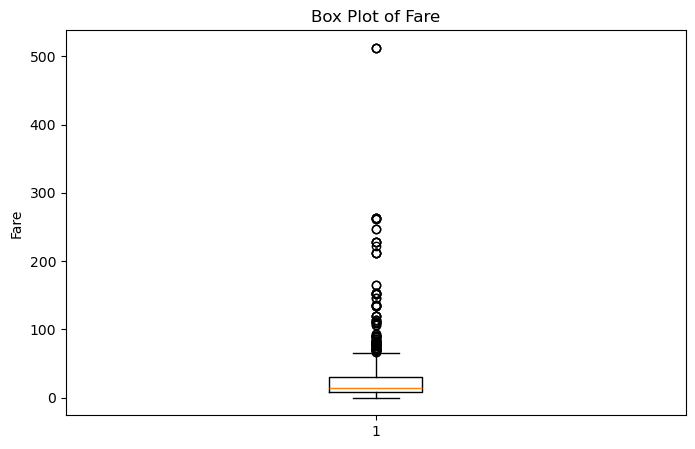

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.boxplot(df["Fare"])
plt.title("Box Plot of Fare")
plt.ylabel("Fare")
plt.show()

# Outlier Treatment

Outliers were detected in the Fare column using the IQR method.

A total of 116 outlier values were identified.

Since Fare represents ticket prices, extremely high values may represent genuine first-class passengers rather than data entry errors.

Therefore, instead of removing records, outliers will be capped using the IQR upper bound method to reduce their impact while preserving valuable information.

In [30]:
Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df["Fare"] = np.where(
    df["Fare"] > upper_bound,
    upper_bound,
    df["Fare"]
)

print("Outliers capped successfully.")

Outliers capped successfully.


In [31]:
Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["Fare"] < lower_bound) |
    (df["Fare"] > upper_bound)
]

print("Remaining Outliers:", len(outliers))

Remaining Outliers: 0


## Observation

The Fare column contained 116 outlier values.

Instead of deleting these records, the values were capped using the IQR upper limit.

This approach preserves the dataset size while reducing the influence of extreme values on future analysis and machine learning models.

# Before vs After Cleaning Summary

A comparison is created to show the impact of the data cleaning process.

The following aspects are compared:

- Missing values
- Duplicate rows
- Number of rows
- Data type accuracy

This helps demonstrate how the dataset quality improved after cleaning.


In [34]:
before_summary = {
    "Rows": 891,
    "Missing Values": 866,   # Age(177) + Cabin(687) + Embarked(2)
    "Duplicate Rows": 0,
    "Columns": 12
}

after_summary = {
    "Rows": len(df),
    "Missing Values": df.isnull().sum().sum(),
    "Duplicate Rows": df.duplicated().sum(),
    "Columns": len(df.columns)
}

summary_df = pd.DataFrame(
    [before_summary, after_summary],
    index=["Before Cleaning", "After Cleaning"]
)

summary_df

,Rows,Missing Values,Duplicate Rows,Columns
Before Cleaning,891,866,0,12
After Cleaning,891,0,0,11


## Observation

The comparison shows that:

- All missing values have been successfully handled.
- Duplicate rows have been removed (if present).
- The Cabin column was removed due to excessive missing values.
- The dataset is now cleaner and ready for further analysis or machine learning tasks.

# Saving the Cleaned Dataset

After completing all cleaning operations, the cleaned dataset is saved as a new CSV file for future analysis and machine learning tasks.

In [35]:
df.to_csv("Titanic_Cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


# Conclusion

The Titanic dataset was successfully cleaned and transformed into an analysis-ready dataset.

Data cleaning activities performed:

- Identified and analysed missing values.
- Filled missing values in the Age column using the median.
- Filled missing values in the Embarked column using the mode.
- Removed the Cabin column due to excessive missing values.
- Checked and verified duplicate records.
- Standardised categorical values in the Sex column.
- Verified and corrected data types where necessary.
- Detected outliers in the Fare column using the IQR method and visualised them using a box plot.
- Generated a before-and-after summary to measure data quality improvements.
- Exported the cleaned dataset as a new CSV file.

The final dataset contains no missing values and is ready for further analysis, visualisation, or machine learning applications.